# 01 — Data exploration
Inspect the local tool datasets plus the supervised intent-router corpora. Hotel, attraction and restaurant data are deterministic synthetic records; weather/FX also have live provider modes.


In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().resolve().parent if Path.cwd().name == '02_notebooks' else Path.cwd().resolve()
SRC = ROOT / '03_src'
if str(SRC) not in sys.path: sys.path.insert(0, str(SRC))

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = ROOT/'01_data'/'raw'
files = ['cities.csv','hotels.csv','attractions.csv','restaurants.csv','transport.csv','weather_fallback.csv','sample_user_queries.csv','intent_router_dataset.csv','intent_router_challenge.csv']
frames = {f: pd.read_csv(data/f) for f in files}
{k: v.shape for k,v in frames.items()}


{'cities.csv': (60, 11),
 'hotels.csv': (18000, 19),
 'attractions.csv': (9000, 12),
 'restaurants.csv': (9000, 13),
 'transport.csv': (60, 12),
 'weather_fallback.csv': (7200, 9),
 'sample_user_queries.csv': (25000, 3),
 'intent_router_dataset.csv': (60000, 11),
 'intent_router_challenge.csv': (5000, 4)}

In [3]:
frames['hotels.csv'].head()

,hotel_id,city,country,name,area,stars,rating,nightly_eur,review_count,breakfast_included,refundable,distance_to_center_km,wifi,workspace,family_rooms,air_conditioning,parking,pet_friendly,accessible
0,H0010001,Vienna,Austria,Central Vienna Hotel 001,Centre,1,3.7,87,25,0,0,0.1,1,1,1,0,1,1,1
1,H0010002,Vienna,Austria,Grand Vienna Residence 002,Museum District,2,4.0,130,162,1,1,1.8,1,0,0,1,1,0,1
2,H0010003,Vienna,Austria,Urban Vienna Suites 003,Market District,3,3.9,208,299,1,0,3.5,1,1,0,1,0,0,1
3,H0010004,Vienna,Austria,Riverside Vienna Rooms 004,Harbour,4,4.0,223,436,0,1,5.2,1,0,0,1,0,0,0
4,H0010005,Vienna,Austria,Old Town Vienna House 005,Centre,5,4.9,155,573,1,0,6.9,1,1,0,0,0,0,1


In [4]:
summary = frames['hotels.csv'].groupby('city').agg(hotels=('hotel_id','count'), median_price=('nightly_eur','median'), avg_rating=('rating','mean')).sort_values('median_price',ascending=False)
summary.head(15)

,hotels,median_price,avg_rating
city,,,
Stockholm,300,216.0,4.079667
Reykjavik,300,215.0,4.092000
Istanbul,300,212.0,4.076333
Zagreb,300,212.0,4.099000
Innsbruck,300,210.0,4.068333
Venice,300,209.0,4.091667
Amsterdam,300,209.0,4.103333
Florence,300,208.5,4.081333
Copenhagen,300,207.0,4.073333


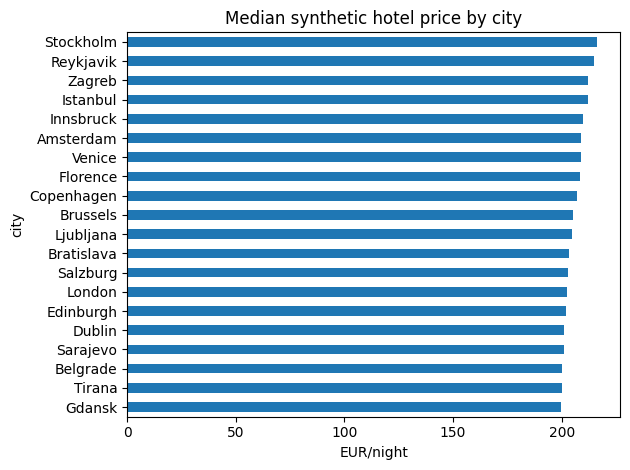

In [5]:
summary['median_price'].head(20).sort_values().plot(kind='barh', title='Median synthetic hotel price by city'); plt.xlabel('EUR/night'); plt.tight_layout(); plt.show()

In [6]:
frames['attractions.csv'].groupby('category').size().sort_values(ascending=False)

category
aquarium            600
botanical_garden    600
castle              600
church              600
food_hall           600
gallery             600
historic_site       600
landmark            600
market              600
museum              600
neighborhood        600
park                600
science_museum      600
viewpoint           600
zoo                 600
dtype: int64

## Restaurant catalogue
Inspect cuisine coverage and average meal cost.


In [7]:
frames['restaurants.csv'].groupby('cuisine').agg(restaurants=('restaurant_id','count'), avg_meal_eur=('avg_meal_eur','mean'), avg_rating=('rating','mean')).sort_values('restaurants', ascending=False)


,restaurants,avg_meal_eur,avg_rating
cuisine,,,
asian,750,41.401333,3.9992
bakery,750,41.422667,4.0984
cafe,750,41.401333,3.9992
fine_dining,750,41.444000,3.9984
indian,750,41.306667,4.1000
italian,750,41.410667,4.0992
local,750,41.389333,4.0000
mediterranean,750,41.392000,4.1008
middle_eastern,750,41.297333,4.0000


## Intent-router dataset
The clean split and the separate challenge set serve different purposes: clean split checks in-family routing, challenge data tests indirect/noisy/generalization behavior.


In [8]:
router = frames['intent_router_dataset.csv']
print(router['split'].value_counts())
print(router['language'].value_counts())
router['label_count'] = router['tool_labels'].str.count('\|') + 1
router['label_count'].value_counts().sort_index()


split
train         50000
validation     5000
test           5000
Name: count, dtype: int64
language
en    47500
hu    12500
Name: count, dtype: int64


<>:4: SyntaxWarning: invalid escape sequence '\|'
<>:4: SyntaxWarning: invalid escape sequence '\|'
/tmp/ipykernel_4377/2849395790.py:4: SyntaxWarning: invalid escape sequence '\|'
  router['label_count'] = router['tool_labels'].str.count('\|') + 1


label_count
1    36666
2    13334
3    10000
Name: count, dtype: int64

In [9]:
challenge = frames['intent_router_challenge.csv']
print('challenge rows:', len(challenge))
challenge.head()


challenge rows: 5000


,query_id,query,tool_labels,city
0,CH00001,Should I pack an umbrella for Lisbon for the n...,weather,Lisbon
1,CH00002,I still need a place to stay overnight in Brat...,hotel,Bratislava
2,CH00003,Build me a list of things worth seeing in Lyon...,attractions|location,Lyon
3,CH00004,How do I get around Florence without a car for...,transport|weather,Florence
4,CH00005,I want somewhere good to eat in Warsaw around ...,restaurant,Warsaw
